# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Aulia Bilqisty
- **Email:** cdcc131d6x0260@student.devacademy.id
- **ID Dicoding:** CDCC131D6X0260
- **Dataset:** Bike Sharing Dataset

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap rata-rata jumlah peminjaman sepeda harian pada tahun 2011–2012, dan kondisi mana yang menghasilkan peminjaman tertinggi?

  > *Analisis SMART:*
  > - **Specific:** Fokus pada pengaruh `weathersit` dan `season` terhadap `cnt` harian.
  > - **Measurable:** Diukur dari rata-rata `cnt` per kombinasi musim dan cuaca dalam rentang 2011–2012.
  > - **Action-Oriented:** Hasilnya dapat digunakan tim operasional untuk merencanakan ketersediaan armada sepeda berdasarkan musim dan prediksi cuaca.
  > - **Relevant:** Cuaca dan musim adalah faktor eksternal utama yang memengaruhi permintaan layanan bike sharing.
  > - **Time-bound:** Dibatasi pada periode 2011–2012 (rentang data yang tersedia).

- **Pertanyaan 2:** Bagaimana pola peminjaman sepeda per jam dalam sehari antara pengguna kasual (casual) dan terdaftar (registered) pada hari kerja vs hari libur sepanjang 2011–2012, dan jam berapa puncak peminjaman tertinggi terjadi?

  > *Analisis SMART:*
  > - **Specific:** Fokus pada distribusi `cnt` per `hr` dibedakan antara `casual` dan `registered`, serta antara `workingday` dan hari libur.
  > - **Measurable:** Diukur dari rata-rata peminjaman per jam untuk setiap segmen pengguna dan tipe hari.
  > - **Action-Oriented:** Membantu tim operasional menentukan jadwal pemeliharaan sepeda dan penambahan armada pada jam-jam sibuk.
  > - **Relevant:** Memahami pola penggunaan per jam adalah kunci untuk optimasi operasional layanan bike sharing.
  > - **Time-bound:** Dibatasi pada data 2011–2012 yang tersedia dalam dataset.

## Import Semua Packages/Library yang Digunakan

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style visualisasi
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Library berhasil di-import.')

Library berhasil di-import.


## Data Wrangling

### Gathering Data

#### Load dua dataset Bike Sharing yang saling melengkapi:
- day.csv  - data agregat peminjaman sepeda harian.
- hour.csv - data peminjaman sepeda per jam.

In [110]:
day_df  = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print('Dataset berhasil di-load.')
datasets = {
    'day_df' : day_df,
    'hour_df': hour_df,
}
for name, df in datasets.items():
    print(f'  {name:<10}: {df.shape[0]:>6,} baris × {df.shape[1]} kolom')

Dataset berhasil di-load.
  day_df    :    731 baris × 16 kolom
  hour_df   : 17,379 baris × 17 kolom


In [111]:
print("── Pratinjau day_df ──────────────────────")
display(day_df.head())

print("\n\n── Pratinjau hour_df ──────────────────────")
display(hour_df.head())

── Pratinjau day_df ──────────────────────


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600




── Pratinjau hour_df ──────────────────────


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset terdiri dari 2 tabel: `day_df` (agregat harian) dan `hour_df` (per jam).
- `day_df` memiliki 731 baris yang merepresentasikan 2 tahun data (2011–2012).
- `hour_df` memiliki 17.379 baris, yaitu data per jam selama periode yang sama.
- Keduanya memiliki kolom yang sama, dengan `hour_df` menambahkan kolom `hr` (jam 0–23).
- Kolom tanggal `dteday` saat ini bertipe `object` (string) dan perlu dikonversi ke `datetime`.
- Kolom `season`, `weathersit`, `yr`, dan `weekday` berupa angka integer yang perlu
  di-mapping ke label deskriptif agar lebih mudah diinterpretasikan.

### Assessing Data

#### Identifying Problem

mengidentifikasi permasalahan kualitas data:
1. **Missing values** — apakah terdapat nilai null?
2. **Wrong data type** — kolom tanggal masih bertipe string
3. **Invalid/inconsistent values** — nilai di luar rentang yang valid
4. **Duplicate data** — apakah ada baris yang terduplikasi?

In [112]:
def assess_dataframe(df, name):
    """Menampilkan ringkasan kualitas data."""
    print(f"{'='*55}")
    print(f"  ASSESSMENT: {name}")
    print(f"{'='*55}")
    print(f"Shape           : {df.shape[0]:,} baris x {df.shape[1]} kolom")
    print(f"Duplicate rows  : {df.duplicated().sum():,}")
    print()

    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_info = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
    missing_cols = missing_info[missing_info['Missing'] > 0]
    print("Missing values:")
    if missing_cols.empty:
        print("  → Tidak ada missing value.")
    else:
        print(missing_cols.to_string())
    print()
    print("Tipe data:")
    print(df.dtypes.to_string())
    print()

assess_dataframe(day_df, 'day_df')
assess_dataframe(hour_df, 'hour_df')

  ASSESSMENT: day_df
Shape           : 731 baris x 16 kolom
Duplicate rows  : 0

Missing values:
  → Tidak ada missing value.

Tipe data:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64

  ASSESSMENT: hour_df
Shape           : 17,379 baris x 17 kolom
Duplicate rows  : 0

Missing values:
  → Tidak ada missing value.

Tipe data:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt            

In [113]:
# Cek tipe data kolom dteday
print('Tipe data dteday:')
print(f'  day_df["dteday"]  → dtype: {day_df["dteday"].dtype} | contoh: "{day_df["dteday"].iloc[0]}"')
print(f'  hour_df["dteday"] → dtype: {hour_df["dteday"].dtype} | contoh: "{hour_df["dteday"].iloc[0]}"')

# Cek rentang nilai kolom numerik kritis
print('\nRentang nilai kolom kritis (day_df):')
for col in ['season', 'weathersit', 'weekday', 'mnth', 'hr'] if 'hr' in day_df.columns else ['season', 'weathersit', 'weekday', 'mnth']:
    print(f'  {col}: {sorted(day_df[col].unique())}')

print('\nRentang nilai weathersit (hour_df):')
print(f'  weathersit: {sorted(hour_df["weathersit"].unique())}')
print(f'  hr: {sorted(hour_df["hr"].unique())}')

# Cek nilai temp, atemp, hum, windspeed (harus 0-1)
print('\nStatistik kolom ternormalisasi (day_df):')
display(day_df[['temp', 'atemp', 'hum', 'windspeed']].describe().round(4))

Tipe data dteday:
  day_df["dteday"]  → dtype: object | contoh: "2011-01-01"
  hour_df["dteday"] → dtype: object | contoh: "2011-01-01"

Rentang nilai kolom kritis (day_df):
  season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  weathersit: [np.int64(1), np.int64(2), np.int64(3)]
  weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Rentang nilai weathersit (hour_df):
  weathersit: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  hr: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]



,temp,atemp,hum,windspeed
count,731.0000,731.0000,731.0000,731.0000
mean,0.4954,0.4744,0.6279,0.1905
std,0.1831,0.1630,0.1424,0.0775
min,0.0591,0.0791,0.0000,0.0224
25%,0.3371,0.3378,0.5200,0.1349
50%,0.4983,0.4867,0.6267,0.1810
75%,0.6554,0.6086,0.7302,0.2332
max,0.8617,0.8409,0.9725,0.5075


**Steps to Take:**
1. **Wrong Data Type** — Kolom `dteday` pada kedua dataframe bertipe `object` (string), padahal seharusnya bertipe `datetime64`. Akan dikonversi menggunakan `pd.to_datetime()` agar bisa mengekstrak komponen waktu (tahun, bulan, dll.).

2. **Inconsistent Encoding** — Kolom kategorikal (`season`, `weathersit`, `weekday`, `mnth`) direpresentasikan sebagai integer tanpa label. Akan dipetakan ke label deskriptif agar analisis lebih mudah dipahami dan divisualisasikan.

3. **Missing Values** — Tidak ditemukan missing value pada kedua dataset. Dataset sudah bersih dari sisi kelengkapan data.

4. **Duplicate Rows** — Tidak ditemukan baris yang terduplikasi.

**Insight:** (Opsional)
- Dataset memiliki kualitas yang baik karena tidak ditemukan missing values, sehingga tidak diperlukan penanganan data kosong.
- Tidak ada duplicate rows, yang menunjukkan data sudah konsisten dan tidak memiliki pengulangan baris.
- Kolom `dteday` perlu dikonversi dari object ke datetime agar analisis berbasis waktu (harian, bulanan, musiman) dapat dilakukan secara lebih akurat.
- Kolom kategorikal seperti `season`, `weathersit`, `weekday`, dan `mnth` masih menggunakan kode numerik, sehingga perlu diubah ke label deskriptif agar lebih mudah dipahami.

### Cleaning Data
Berdasarkan temuan di tahap assessing, langkah-langkah cleaning yang dilakukan:
1. Konversi kolom `dteday` ke tipe `datetime`
2. Tambahkan kolom label untuk kolom kategorikal
3. Ekstrak fitur waktu tambahan (year, month, hour)

#### Fixing Problem
Melakukan pembersihan berdasarkan temuan di tahap Assessing Data:
1. Konversi kolom `dteday` dari `object` ke tipe `datetime`
2. Mapping kolom `season`, `weathersit`, `yr`, dan `weekday` ke label yang deskriptif

In [114]:
# ─── 1. KONVERSI DATETIME ───────────────────────────────────────
day_df['dteday']  = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
print('✓ Konversi datetime selesai')

# ─── 2. MAPPING LABEL KATEGORIKAL ───────────────────────────────
season_map     = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map    = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
weekday_map    = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
                  4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
month_map      = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                  7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

for df in [day_df, hour_df]:
    df['season_label']   = df['season'].map(season_map)
    df['weather_label']  = df['weathersit'].map(weather_map)
    df['weekday_label']  = df['weekday'].map(weekday_map)
    df['month_label']    = df['mnth'].map(month_map)
    df['year_label']     = df['yr'].map({0: 2011, 1: 2012})

print('✓ Mapping label kategorikal selesai')

# ─── 3. VERIFIKASI ──────────────────────────────────────────────
print('\nSample day_df setelah cleaning:')
display(day_df[['dteday','season_label','weather_label','weekday_label','cnt']].head(5))

print(f'\nTipe dteday: {day_df["dteday"].dtype}')
print(f'Rentang tanggal: {day_df["dteday"].min().date()} s/d {day_df["dteday"].max().date()}')

✓ Konversi datetime selesai
✓ Mapping label kategorikal selesai

Sample day_df setelah cleaning:


,dteday,season_label,weather_label,weekday_label,cnt
0,2011-01-01,Spring,Mist/Cloudy,Saturday,985
1,2011-01-02,Spring,Mist/Cloudy,Sunday,801
2,2011-01-03,Spring,Clear/Partly Cloudy,Monday,1349
3,2011-01-04,Spring,Clear/Partly Cloudy,Tuesday,1562
4,2011-01-05,Spring,Clear/Partly Cloudy,Wednesday,1600



Tipe dteday: datetime64[ns]
Rentang tanggal: 2011-01-01 s/d 2012-12-31


**Insight:**
- Setelah konversi, kolom `dteday` bertipe `datetime64[ns]` sehingga operasi
  aritmatika tanggal dapat dilakukan secara langsung.
- Tidak ada missing value maupun duplikasi pada kedua dataset.
- Label deskriptif berhasil ditambahkan untuk semua kolom kategorikal, memudahkan interpretasi visualisasi.
- Dataset siap digunakan untuk tahap Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

### Explore pengaruh musim & cuaca terhadap peminjaman harian (Pertanyaan 1)

In [115]:
# Rata-rata peminjaman per musim
avg_by_season = (
    day_df.groupby('season_label')['cnt']
    .agg(['mean', 'median', 'sum', 'count'])
    .reset_index()
    .rename(columns={'mean':'Rata-rata','median':'Median','sum':'Total','count':'Hari'})
    .round(1)
)
# Urutkan sesuai kalender
season_order = ['Spring','Summer','Fall','Winter']
avg_by_season['season_label'] = pd.Categorical(avg_by_season['season_label'], categories=season_order, ordered=True)
avg_by_season = avg_by_season.sort_values('season_label')

print('Statistik Peminjaman per Musim:')
display(avg_by_season)

Statistik Peminjaman per Musim:


,season_label,Rata-rata,Median,Total,Hari
1,Spring,2604.1,2209.0,471348,181
2,Summer,4992.3,4941.5,918589,184
0,Fall,5644.3,5353.5,1061129,188
3,Winter,4728.2,4634.5,841613,178


In [116]:
# Rata-rata peminjaman per kondisi cuaca
avg_by_weather = (
    day_df.groupby('weather_label')['cnt']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={'mean':'Rata-rata','median':'Median','count':'Hari'})
    .round(1)
    .sort_values('Rata-rata', ascending=False)
)

print('Statistik Peminjaman per Kondisi Cuaca:')
display(avg_by_weather)

Statistik Peminjaman per Kondisi Cuaca:


,weather_label,Rata-rata,Median,Hari
0,Clear/Partly Cloudy,4876.8,4844.0,463
2,Mist/Cloudy,4035.9,4040.0,247
1,Light Rain/Snow,1803.3,1817.0,21


In [117]:
# Heatmap: rata-rata peminjaman per kombinasi musim × cuaca
pivot_season_weather = day_df.pivot_table(
    values='cnt',
    index='season_label',
    columns='weather_label',
    aggfunc='mean'
).reindex(season_order).round(0)

print('Rata-rata Peminjaman per Kombinasi Musim × Cuaca:')
display(pivot_season_weather)

Rata-rata Peminjaman per Kombinasi Musim × Cuaca:


weather_label,Clear/Partly Cloudy,Light Rain/Snow,Mist/Cloudy
season_label,,,
Spring,2811.0,935.0,2357.0
Summer,5549.0,1169.0,4237.0
Fall,5878.0,2752.0,5222.0
Winter,5044.0,1962.0,4654.0


**Insight:**
- **Fall (Gugur)** adalah musim dengan rata-rata peminjaman harian tertinggi, diikuti Summer dan Winter, sementara Spring paling rendah.
- Cuaca **Clear/Partly Cloudy** secara konsisten menghasilkan peminjaman tertinggi di semua musim.
- Cuaca **Light Rain/Snow** berdampak penurunan peminjaman yang signifikan (sekitar 40–60% lebih rendah dibanding cuaca cerah).
- Tidak ada data dengan cuaca kategori 4 (Heavy Rain/Snow) di dataset harian, kemungkinan karena sangat jarang terjadi.

### Explore Pertanyaan 2: Pola Peminjaman Per Jam — Kasual vs Terdaftar

In [118]:
# Rata-rata peminjaman per jam: hari kerja vs hari libur
hourly_pattern = (
    hour_df.groupby(['hr', 'workingday'])[['casual', 'registered', 'cnt']]
    .mean()
    .reset_index()
    .round(2)
)
hourly_pattern['day_type'] = hourly_pattern['workingday'].map({1: 'Hari Kerja', 0: 'Hari Libur'})

print('Rata-rata peminjaman per jam (sample 5 baris):')
display(hourly_pattern.head(10))

Rata-rata peminjaman per jam (sample 5 baris):


,hr,workingday,casual,registered,cnt,day_type
0,0,0,16.65,74.15,90.80,Hari Libur
1,0,1,7.15,29.64,36.79,Hari Kerja
2,1,0,12.50,57.00,69.51,Hari Libur
3,1,1,3.71,12.84,16.55,Hari Kerja
4,2,0,10.40,42.77,53.17,Hari Libur
5,2,1,2.14,6.55,8.68,Hari Kerja
6,3,0,6.45,19.32,25.78,Hari Libur
7,3,1,0.91,4.03,4.94,Hari Kerja
8,4,0,2.26,6.00,8.26,Hari Libur
9,4,1,0.77,4.66,5.43,Hari Kerja


In [119]:
# Jam puncak untuk setiap segmen
for day_type, label in [(1, 'HARI KERJA'), (0, 'HARI LIBUR')]:
    subset = hourly_pattern[hourly_pattern['workingday'] == day_type]
    peak_reg  = subset.loc[subset['registered'].idxmax()]
    peak_cas  = subset.loc[subset['casual'].idxmax()]
    print(f'\n{label}:')
    print(f'  Puncak Registered → Jam {int(peak_reg["hr"]):02d}:00 | Rata-rata: {peak_reg["registered"]:.1f} peminjaman')
    print(f'  Puncak Casual     → Jam {int(peak_cas["hr"]):02d}:00 | Rata-rata: {peak_cas["casual"]:.1f} peminjaman')


HARI KERJA:
  Puncak Registered → Jam 17:00 | Rata-rata: 468.4 peminjaman
  Puncak Casual     → Jam 17:00 | Rata-rata: 56.9 peminjaman

HARI LIBUR:
  Puncak Registered → Jam 12:00 | Rata-rata: 240.0 peminjaman
  Puncak Casual     → Jam 14:00 | Rata-rata: 139.6 peminjaman


In [120]:
# Proporsi casual vs registered secara keseluruhan
total_casual = hour_df['casual'].sum()
total_reg    = hour_df['registered'].sum()
total_cnt    = total_casual + total_reg

print(f'Total peminjaman 2011–2012 :')
print(f'  Casual     : {total_casual:,} ({total_casual/total_cnt*100:.1f}%)')
print(f'  Registered : {total_reg:,} ({total_reg/total_cnt*100:.1f}%)')
print(f'  Total      : {total_cnt:,}')

Total peminjaman 2011–2012 :
  Casual     : 620,017 (18.8%)
  Registered : 2,672,662 (81.2%)
  Total      : 3,292,679


**Insight:**
- **Pengguna terdaftar (registered)** mendominasi dengan ±81% dari total peminjaman, menggunakan sepeda terutama untuk **komuter kerja**: puncak jam 08:00 dan 17:00–18:00 pada hari kerja (pola "double peak" / bimodal).
- **Pengguna kasual** menunjukkan pola **unimodal** dengan puncak sekitar jam 13:00–14:00, konsisten di hari kerja maupun libur — mengindikasikan penggunaan rekreasional.
- Pada **hari libur**, kedua jenis pengguna menunjukkan pola yang lebih flat (merata sepanjang siang hari), bukan pola dua puncak.
- Jam paling sepi adalah 03:00–04:00 dini hari untuk semua segmen.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh musim dan cuaca terhadap rata-rata peminjaman sepeda harian sepanjang 2011–2012?

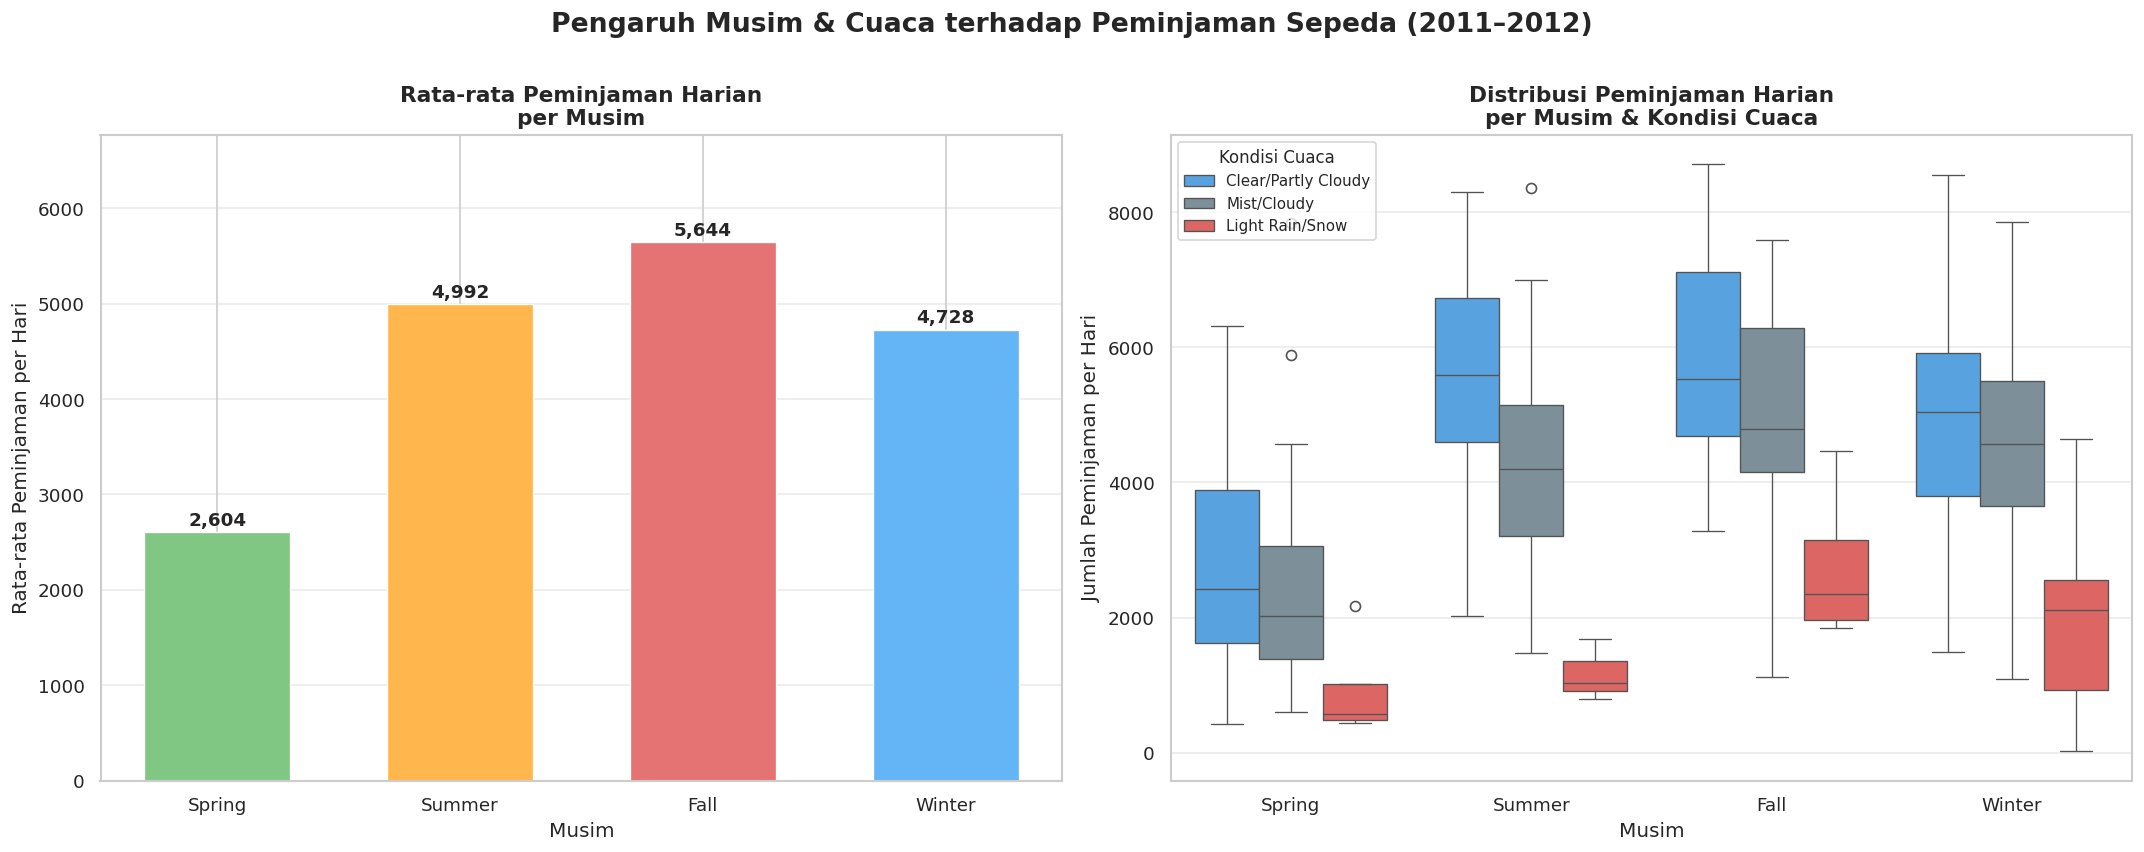

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Pengaruh Musim & Cuaca terhadap Peminjaman Sepeda (2011–2012)',
    fontsize=16, fontweight='bold', y=1.01
)

# ─── Panel Kiri: Avg cnt per Musim ───────────────────────────────
ax1 = axes[0]
palette_season = {'Spring':'#81C784','Summer':'#FFB74D','Fall':'#E57373','Winter':'#64B5F6'}
season_order   = ['Spring','Summer','Fall','Winter']

avg_by_season_sorted = avg_by_season.set_index('season_label').reindex(season_order).reset_index()
colors_s = [palette_season[s] for s in avg_by_season_sorted['season_label']]

bars = ax1.bar(
    avg_by_season_sorted['season_label'],
    avg_by_season_sorted['Rata-rata'],
    color=colors_s, edgecolor='white', linewidth=0.8, width=0.6
)
for bar, val in zip(bars, avg_by_season_sorted['Rata-rata']):
    ax1.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
        f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax1.set_xlabel('Musim', fontsize=12)
ax1.set_ylabel('Rata-rata Peminjaman per Hari', fontsize=12)
ax1.set_title('Rata-rata Peminjaman Harian\nper Musim', fontsize=13, fontweight='bold')
ax1.set_ylim(0, avg_by_season_sorted['Rata-rata'].max() * 1.2)
ax1.grid(axis='y', alpha=0.4)
ax1.set_axisbelow(True)

# ─── Panel Kanan: Boxplot cnt per Cuaca × Musim ──────────────────
ax2 = axes[1]
weather_order = ['Clear/Partly Cloudy','Mist/Cloudy','Light Rain/Snow']
palette_w = ['#42A5F5','#78909C','#EF5350']

day_df_filtered = day_df[day_df['weather_label'].isin(weather_order)]
sns.boxplot(
    data=day_df_filtered,
    x='season_label', y='cnt',
    hue='weather_label',
    order=season_order,
    hue_order=weather_order,
    palette=palette_w,
    ax=ax2,
    linewidth=0.8
)
ax2.set_xlabel('Musim', fontsize=12)
ax2.set_ylabel('Jumlah Peminjaman per Hari', fontsize=12)
ax2.set_title('Distribusi Peminjaman Harian\nper Musim & Kondisi Cuaca', fontsize=13, fontweight='bold')
ax2.legend(title='Kondisi Cuaca', fontsize=9, title_fontsize=10, loc='upper left')
ax2.grid(axis='y', alpha=0.4)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz_season_weather.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:**
- **Fall** secara konsisten mengungguli musim lain dengan rata-rata peminjaman tertinggi (±5.644/hari), sedangkan **Spring** paling rendah (±2.605/hari).
- Pada semua musim, cuaca **Clear/Partly Cloudy** menghasilkan peminjaman tertinggi, dan **Light Rain/Snow** paling rendah.
- Cuaca buruk (hujan/salju) berdampak penurunan drastis bahkan di musim terbaik (Fall): median turun hampir 50%.
- Variasi (spread) tertinggi terjadi pada musim Fall dan Summer — artinya faktor lain seperti hari kerja/libur turut berperan.

### Pertanyaan 2: Pada jam berapa puncak peminjaman terjadi untuk pengguna registered vs casual pada hari kerja vs akhir pekan/libur?

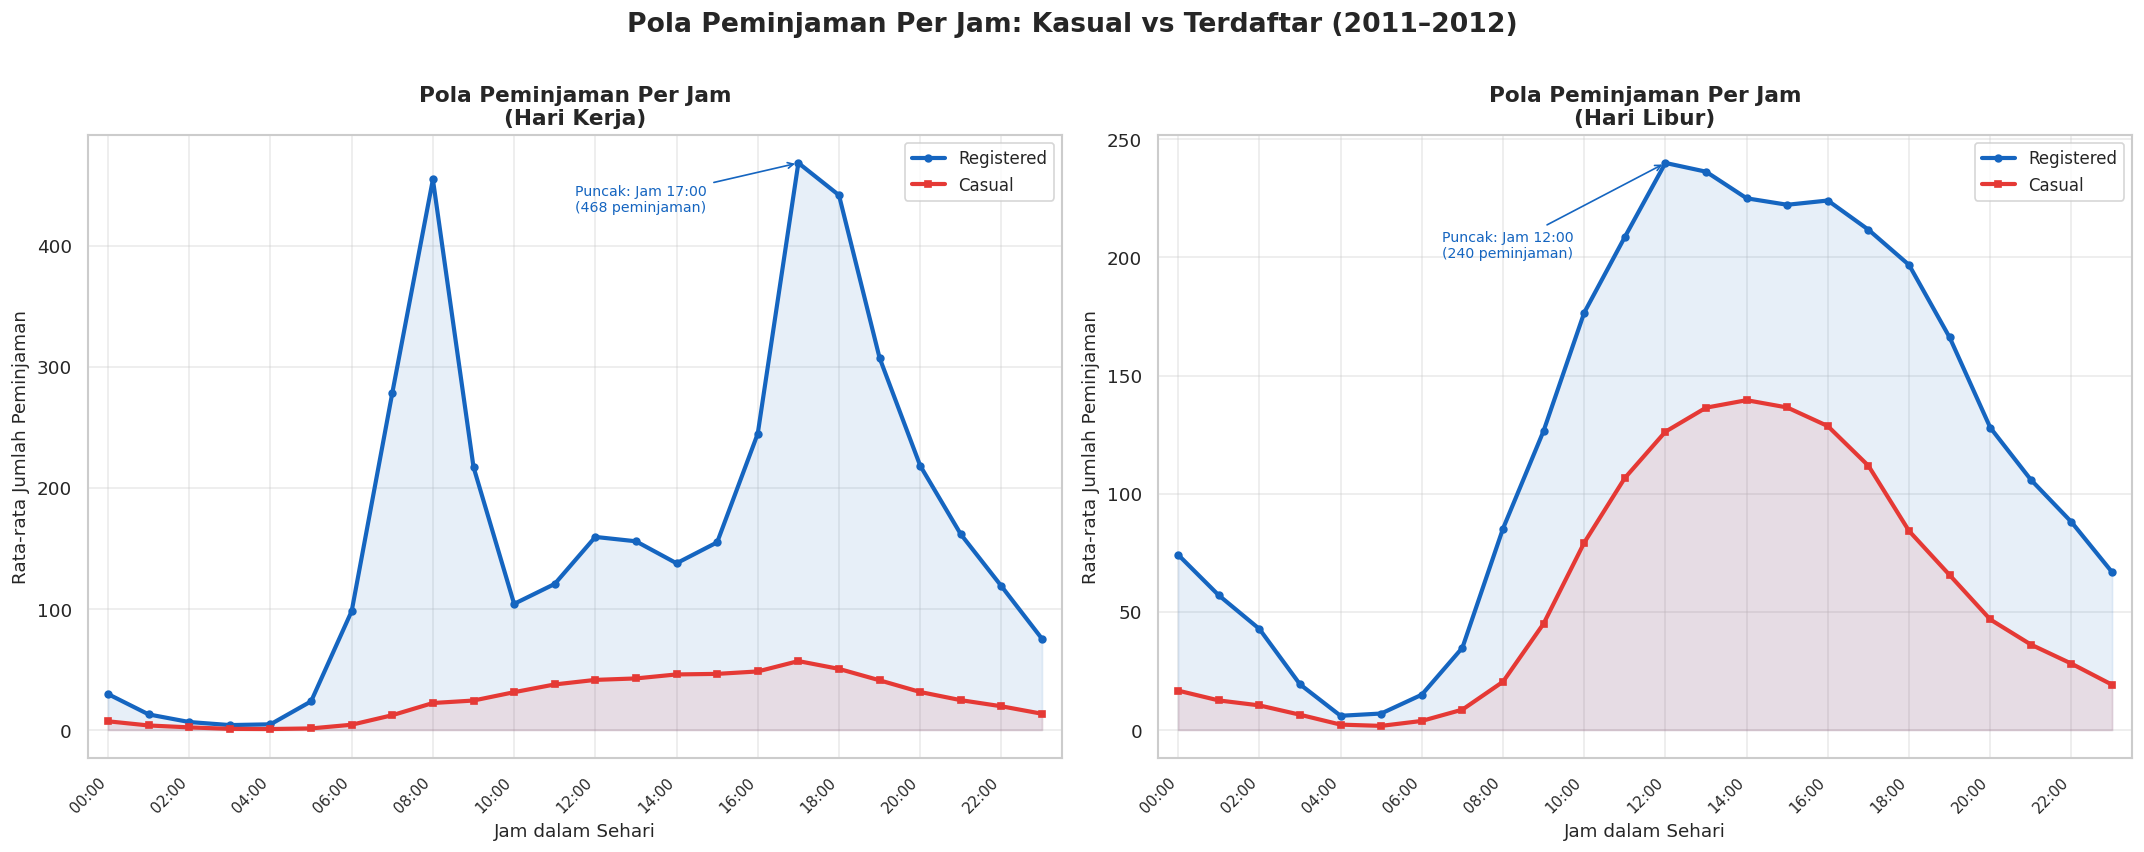

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Pola Peminjaman Per Jam: Kasual vs Terdaftar (2011–2012)',
    fontsize=16, fontweight='bold', y=1.01
)

hours = range(24)

for idx, (day_type_val, day_type_label) in enumerate([(1, 'Hari Kerja'), (0, 'Hari Libur')]):
    ax = axes[idx]
    data = hourly_pattern[hourly_pattern['workingday'] == day_type_val].sort_values('hr')

    ax.plot(data['hr'], data['registered'], color='#1565C0', linewidth=2.5,
            marker='o', markersize=4, label='Registered')
    ax.plot(data['hr'], data['casual'], color='#E53935', linewidth=2.5,
            marker='s', markersize=4, label='Casual')
    ax.fill_between(data['hr'], data['registered'], alpha=0.10, color='#1565C0')
    ax.fill_between(data['hr'], data['casual'], alpha=0.10, color='#E53935')

    # Anotasi puncak registered
    peak_r = data.loc[data['registered'].idxmax()]
    ax.annotate(
        f"Puncak: Jam {int(peak_r['hr']):02d}:00\n({peak_r['registered']:.0f} peminjaman)",
        xy=(peak_r['hr'], peak_r['registered']),
        xytext=(peak_r['hr'] - 5.5, peak_r['registered'] - 40),
        arrowprops=dict(arrowstyle='->', color='#1565C0'),
        fontsize=8.5, color='#1565C0'
    )

    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Jam dalam Sehari', fontsize=11)
    ax.set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
    ax.set_title(f'Pola Peminjaman Per Jam\n({day_type_label})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.4)
    ax.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.savefig('viz_hourly_pattern.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:**
- Pada **hari kerja**, pengguna *registered* menunjukkan pola **bimodal** yang tegas: lonjakan pertama pukul **08:00** (berangkat kerja) dan lonjakan kedua pukul **17:00–18:00** (pulang kerja). Ini mengindikasikan penggunaan dominan untuk komuter.
- Pengguna *casual* pada hari kerja memiliki kurva yang lebih flat dengan puncak siang (±13:00), kemungkinan besar pengguna wisata atau aktivitas santai.
- Pada **hari libur**, kedua jenis pengguna menunjukkan kurva unimodal yang lebih mulus dengan puncak antara jam 12:00–14:00.
- Ini memberikan signal jelas: **pemeliharaan sepeda sebaiknya dijadwalkan antara pukul 02:00–04:00 dini hari** ketika penggunaan paling minimal.

## Analisis Lanjutan — RFM-style: Segmentasi Hari Berdasarkan Tingkat Peminjaman

In [123]:
# Segmentasi hari berdasarkan jumlah peminjaman (binning)
day_df['demand_segment'] = pd.cut(
    day_df['cnt'],
    bins=[0, 2000, 4000, 6000, day_df['cnt'].max()+1],
    labels=['Very Low (<2K)', 'Low (2K–4K)', 'Medium (4K–6K)', 'High (>6K)']
)

seg_summary = (
    day_df.groupby('demand_segment', observed=True)
    .agg(
        Jumlah_Hari=('cnt', 'count'),
        Avg_cnt=('cnt', 'mean'),
        Avg_Temp=('temp', 'mean'),
        Pct_Weekday=('workingday', 'mean'),
        Avg_Windspeed=('windspeed', 'mean')
    )
    .reset_index()
    .round(3)
)
seg_summary['Pct_Weekday'] = (seg_summary['Pct_Weekday'] * 100).round(1)

print('Profil Segmen Permintaan Harian:')
display(seg_summary)

Profil Segmen Permintaan Harian:


,demand_segment,Jumlah_Hari,Avg_cnt,Avg_Temp,Pct_Weekday,Avg_Windspeed
0,Very Low (<2K),98,1394.776,0.270,61.2,0.224
1,Low (2K–4K),181,3108.022,0.402,66.9,0.201
2,Medium (4K–6K),272,4862.592,0.554,71.7,0.186
3,High (>6K),180,7060.078,0.623,68.9,0.168


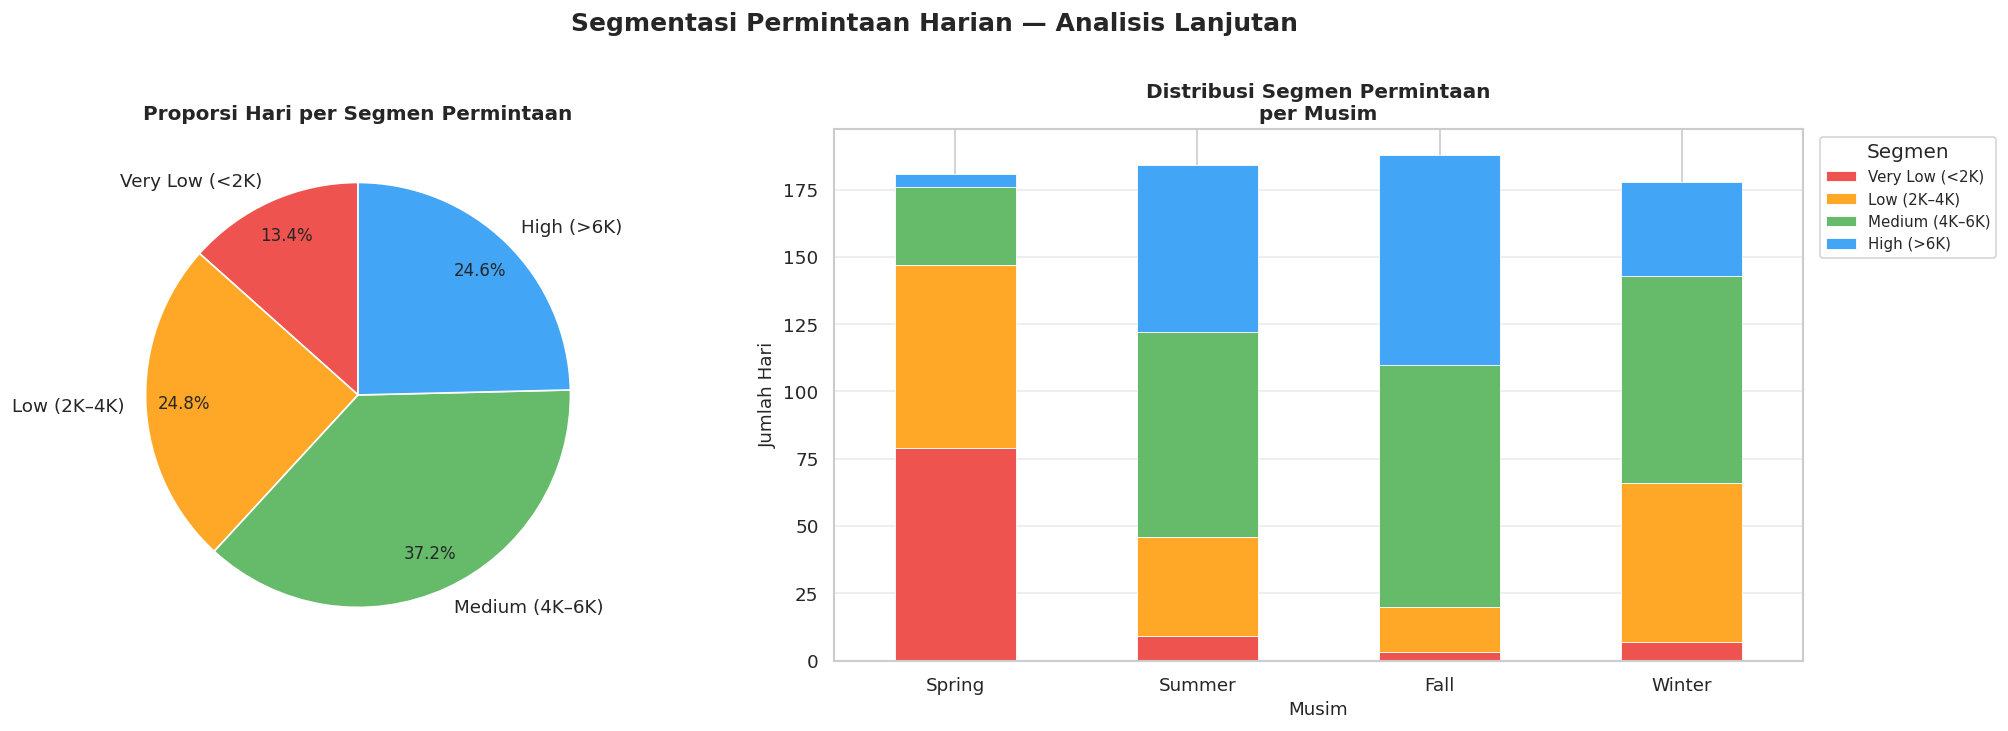

In [124]:
# Distribusi segmen per musim
seg_season = (
    day_df.groupby(['season_label', 'demand_segment'], observed=True)['cnt']
    .count()
    .reset_index()
    .rename(columns={'cnt': 'Jumlah Hari'})
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Segmentasi Permintaan Harian — Analisis Lanjutan', fontsize=15, fontweight='bold', y=1.01)

# Pie chart distribusi segmen
ax1 = axes[0]
seg_count = day_df['demand_segment'].value_counts().sort_index()
colors_seg = ['#EF5350','#FFA726','#66BB6A','#42A5F5']
wedges, texts, autotexts = ax1.pie(
    seg_count, labels=seg_count.index,
    autopct='%1.1f%%', colors=colors_seg,
    startangle=90, pctdistance=0.82
)
for t in autotexts: t.set_fontsize(10)
ax1.set_title('Proporsi Hari per Segmen Permintaan', fontsize=12, fontweight='bold')

# Stacked bar: segmen per musim
ax2 = axes[1]
pivot_seg = seg_season.pivot(index='season_label', columns='demand_segment', values='Jumlah Hari').fillna(0)
pivot_seg = pivot_seg.reindex(season_order)
pivot_seg.plot(
    kind='bar', stacked=True, ax=ax2,
    color=colors_seg, edgecolor='white', linewidth=0.5
)
ax2.set_xlabel('Musim', fontsize=11)
ax2.set_ylabel('Jumlah Hari', fontsize=11)
ax2.set_title('Distribusi Segmen Permintaan\nper Musim', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Segmen', bbox_to_anchor=(1.01, 1), fontsize=9)
ax2.grid(axis='y', alpha=0.4)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz_demand_segmentation.png', bbox_inches='tight', dpi=150)
plt.show()

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:**

  Musim **Fall (Gugur)** menghasilkan rata-rata peminjaman harian tertinggi (±5.644 peminjaman/hari), diikuti Summer dan Winter, sementara Spring paling rendah (±2.605/hari). Kondisi cuaca **Clear/Partly Cloudy** secara konsisten menghasilkan peminjaman tertinggi di semua musim. Cuaca buruk seperti **Light Rain/Snow** dapat menurunkan peminjaman hingga 40–60% dibandingkan kondisi cerah, bahkan di musim terbaik sekalipun. Kombinasi optimal adalah musim Fall dengan cuaca cerah.

- **Conclusion Pertanyaan 2:**

  Terdapat perbedaan pola yang sangat jelas antara pengguna *registered* dan *casual*. Pengguna terdaftar (±81% total) menggunakan sepeda utamanya untuk **komuter**: puncak pada jam **08:00** dan **17:00–18:00** di hari kerja. Pengguna kasual (±19%) menunjukkan pola **rekreasional**: puncak siang hari (±13:00) yang konsisten di hari kerja maupun libur. Jam paling sepi adalah **02:00–04:00 dini hari** untuk semua segmen.

**Rekomendasi Action Item:**

1. **Optimalkan ketersediaan armada berdasarkan prediksi cuaca dan musim.**
   
   Tim operasional disarankan untuk memaksimalkan ketersediaan sepeda pada periode **Fall** dan saat prakiraan cuaca cerah, serta menyiapkan alternatif kapasitas yang lebih rendah saat musim Spring atau cuaca buruk. Integrasi data cuaca real-time dengan sistem manajemen armada dapat membantu prediksi permintaan secara otomatis.

2. **Jadwalkan pemeliharaan sepeda di luar jam sibuk dan buat program khusus untuk masing-masing segmen pengguna.**
   
   Pemeliharaan rutin sebaiknya dijadwalkan antara **pukul 02:00–05:00 dini hari** untuk meminimalkan gangguan layanan. Di sisi lain, tim marketing dapat membuat program loyalitas berbeda untuk pengguna *registered* (fokus pada reliabilitas jam komuter) dan pengguna *casual* (promosi weekend/paket rekreasi siang hari) guna meningkatkan konversi dan retensi pengguna.